# 8-1. DBSCAN의 성능 평가

## DBSCAN의 파라미터 결정

### □ eps 파라미터의 결정 과정

`min_samples 고정 (= minPts)` → `k-distance plot 확인` → `eps 기준값 도출` → `군집 수행`

> eps 기준값의 주변 후보들에 대한 군집을 수행하고 결과를 비교해서 흔들리지 않는 안정 구간을 찾아야 한다.

### □ min_samples 고정하기

- min_samples는 **"몇 명 이상 모여야 무리로 볼까"**를 정하는 값

| 상황 | 권장 min_samples |
|---|---|
| 일반적인 경우 | 5 ~ 10 |
| 군집에 사용되는 변수가 2~3개 데이터 셋 | 3 ~ 6 |
| 군집에 사용되는 변수가 5~10인 데이터 셋 | 8 ~ 15 |
| 군집에 사용되는 변수가 10개 이상인 데이터 셋 | 15 이상 |

> 변수가 많을수록 데이터가 넓게 퍼지므로 기준을 높여야 한다.


## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame
import numpy as np

# 군집분석 관련 참조 (군집 자체는 my_cluster.dbscan()이 수행한다)
from sklearn.neighbors import NearestNeighbors

# 엘보우 포인트를 자동으로 찾아주는 라이브러리
from kneed import KneeLocator

# 두 군집 결과의 일치도
from sklearn.metrics import adjusted_rand_score

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/

⚠️  'jussam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.17, 최신 버전: 0.5.19)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade jussam



### 2. 데이터 불러오기 + 스케일링

In [2]:
origin = load_data("game_usage")
df = my_prep.scaling(origin, method="standard", verbose=False)
df.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,-0.251,1.475
1,0.326,0.607
2,-0.612,0.795
3,0.471,1.675
4,-1.405,-1.559


### 3. min_samples 고정

- min_samples는 **"몇 개 이상 모여 있어야 무리로 볼까"**를 정하는 값
- 이 데이터는 변수가 2개(time spent, game level)이므로 3으로 고정

| 변수 개수 | 권장 min_samples |
|---|---|
| 2~3 | 3~6 |
| 5~10 | 8~15 |
| 10 이상 | 15 이상 |


In [3]:
min_samples = 3

## #02. k-distance plot

### □ k-distance plot 이란?

eps를 정하기 위한 그래프

- 각 데이터마다 **"내 k번째 이웃은 얼마나 멀리 있나"**를 측정해서, 그 값들을 작은 순서대로 줄 세운 그래프
  - DBSCAN 결과는 **eps**에 따라 완전히 달라진다.
  - 초기에는 eps를 얼마로 해야 할지 알 수 없다.
  - k-distance plot을 통해 거리의 분포를 직접 눈으로 보면 어디까지가 "가까운 것"인지 판단할 수 있다.

### □ k-distance plot의 한계

| 한계 | 설명 |
|---|---|
| 주관적이다 | 꺾이는 지점을 사람마다 다르게 본다 |
| 변수가 많으면 흐려진다 | 거리들이 다 비슷해져서 꺾임이 안 보인다 |
| 후보를 줄 뿐이다 | 최종 결정은 결과를 보고 해야 한다 |


### 1. 각 데이터에서 k번째 이웃까지의 거리 구하기

In [4]:
k = min_samples      # k = min_samples 로 설정

# 각 데이터에서 가까운 순서로 k개의 이웃을 찾는다
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(df)

# distance[i] = i번째 데이터에서 이웃들까지의 거리 (가까운 순)
distance, indices = neighbors.kneighbors(df)

# 마지막 열(= k번째 이웃까지의 거리)만 뽑아서 작은 순으로 정렬
target = np.sort(distance[:, k - 1])
target

array([0.10111015, 0.11039822, 0.11625223, 0.11988511, 0.12172144,
       0.12285113, 0.12769295, 0.12769295, 0.12836733, 0.12836733,
       0.12836733, 0.14619664, 0.14620339, 0.14936701, 0.14972662,
       0.14972662, 0.15325497, 0.15557345, 0.15678809, 0.15678809,
       0.15843153, 0.1588343 , 0.16323203, 0.16697634, 0.16697634,
       0.17807115, 0.17867241, 0.17867241, 0.1803835 , 0.18096788,
       0.18305073, 0.18332275, 0.18890987, 0.18890987, 0.19313888,
       0.19721127, 0.20223342, 0.2034414 , 0.2034414 , 0.21075165,
       0.21265306, 0.2164602 , 0.21735497, 0.21735497, 0.21840257,
       0.21891561, 0.22011805, 0.22405052, 0.22412868, 0.22412868,
       0.2293733 , 0.23202731, 0.23336017, 0.23997564, 0.24073719,
       0.24336383, 0.25066886, 0.25104255, 0.25735751, 0.25735751,
       0.26275573, 0.26444959, 0.26650157, 0.268372  , 0.27569735,
       0.27651041, 0.28918464, 0.28923923, 0.29007322, 0.29212993,
       0.29212993, 0.29240678, 0.29286115, 0.30298035, 0.31153

#### 결과 확인

- `kneighbors()`는 자기 자신을 0번 이웃으로 포함해서 돌려준다 → `distance[:, 2]`는 자기 자신 + 이웃 2개
- 즉 `target[i]` = **"자기 포함 3개(min_samples)를 채우려면 반경을 얼마까지 벌려야 하는가"**
- 이것이 곧 DBSCAN의 core point 판정 조건과 같은 계산 → **k-distance plot이 eps의 근거가 되는 이유**

**정렬한 이유**
- 정렬을 하지 않으면 x축은 단순히 아무 의미 없는 데이터 셋 상의 나열 순서가 된다
- 정렬하면 x축이 **밀도 순위**가 되어, 끝에서 치솟는 모양으로 꺾이는 지점을 눈으로 찾을 수 있다

**값의 크기 = 그 점 주변의 밀도**

| 위치 | 값 | 의미 |
|---|---|---|
| 맨 앞 | 0.1011 | 조금만 벌려도 이웃이 찬다 → 군집 한복판 |
| 중앙값(median) | 0.2268 | 보통 밀도 |
| 맨 뒤 | 0.7526 | 한참 벌려야 겨우 찬다 → 외톨이 |


### 2. 꺾이는 지점 찾기 (Elbow Point)

In [5]:
# 3단원에서 배운 KneeLocator를 그대로 쓴다.
# 오른쪽 위로 치솟는 모양이므로 direction="increasing" 으로 설정

# 0부터 len(target)까지의 순서를 x축으로, target을 y축으로 한 그래프의
# 꺾이는 지점을 찾아서 eps 후보를 구한다
# - 그래프 모양 : convex, increasing
kl = KneeLocator(range(0, len(target)), target,
                  curve="convex", direction="increasing")

eps = kl.elbow_y      # 꺾이는 지점의 '거리' → 이것이 eps 후보
point = kl.elbow       # 꺾이는 지점의 '순서'

print(f"eps 후보: {eps:.4f}")
print(f"꺾이는 위치: {point}번째 데이터 (전체 {len(target)}개 중)")

# 실행 결과 예시
# eps 후보: 0.4125
# 꺾이는 위치: 91번째 데이터 (전체 100개 중)

eps 후보: 0.4125
꺾이는 위치: 91번째 데이터 (전체 100개 중)


### 3. 시각화

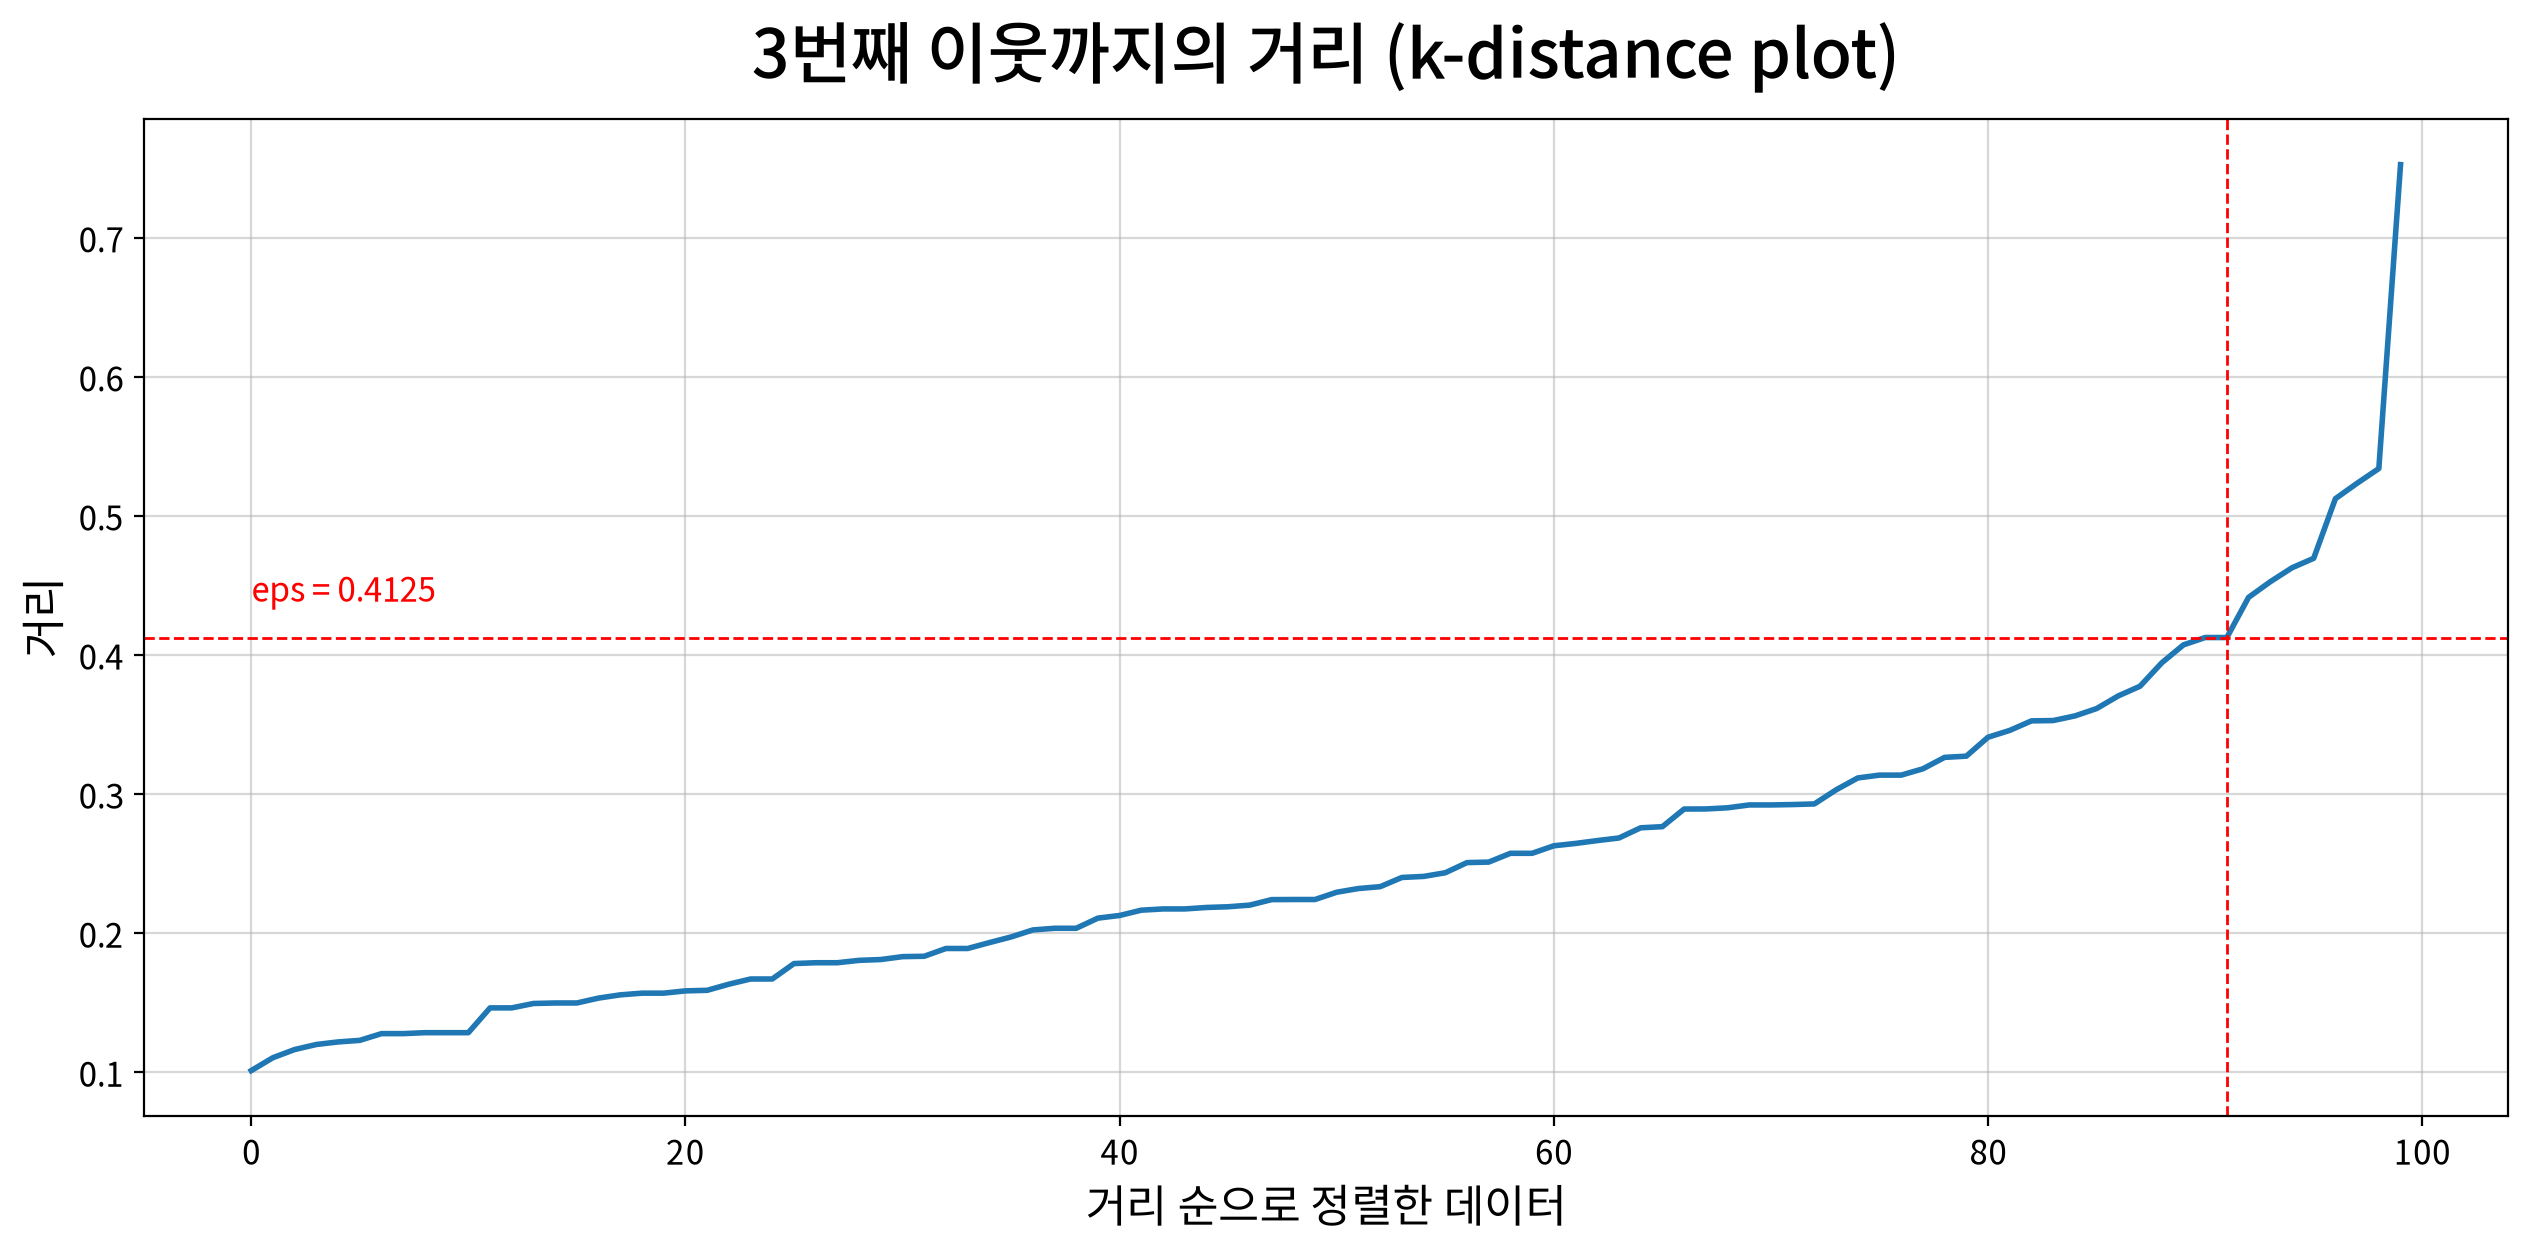

In [6]:
fig, ax = my_plot.init(title=f"{k}번째 이웃까지의 거리 (k-distance plot)",
                         xlabel="거리 순으로 정렬한 데이터", ylabel="거리")

my_plot.lineplot(x=list(range(0, len(target))), y=target, ax=ax)

# 꺾이는 지점 표시
ax.axhline(eps, color="red", linestyle="--", linewidth=1)
ax.axvline(point, color="red", linestyle="--", linewidth=1)
ax.text(0, eps + 0.02, f"eps = {eps:.4f}", color="red", va="bottom")

my_plot.show()

#### 결과 확인

| 구간 | 의미 |
|---|---|
| 왼쪽의 완만한 구간 | 이웃이 가까이 있다 → 빽빽한 곳(군집 내부) |
| 오른쪽의 급격히 치솟는 구간 | 이웃이 멀다 → 띄엄띄엄한 곳 |
| 꺾이는 지점 (elbow) | 이 둘의 경계 → 적정 eps 후보 |

> 꺾이는 지점의 **세로축** 값이 eps 후보다. (가로축이 아니다!)

- 그래프의 오른쪽 끝이 급격히 치솟는 것이 보인다
- 저 구간에 있는 데이터들이 바로 **"이웃이 멀리 있는 외톨이"**, 즉 노이즈 후보다
- 빨간 가로선(eps)보다 위에 있는 데이터들이 노이즈로 분류될 가능성이 높다


### 4. 도출된 eps와 k값을 활용한 군집 (1/2)

[DBSCAN] eps = 0.41251429498079606, min_samples = 3, 거리 = euclidean
  · 군집 수 = 3개 (노이즈 제외)
  · 노이즈 = 3개 (전체의 3.0%)


,그룹번호,데이터수,비율(%),핵심벡터,외곽벡터
0,-1,3,3.000,0,0
1,0,82,82.000,77,5
2,1,3,3.000,3,0
3,2,12,12.000,12,0


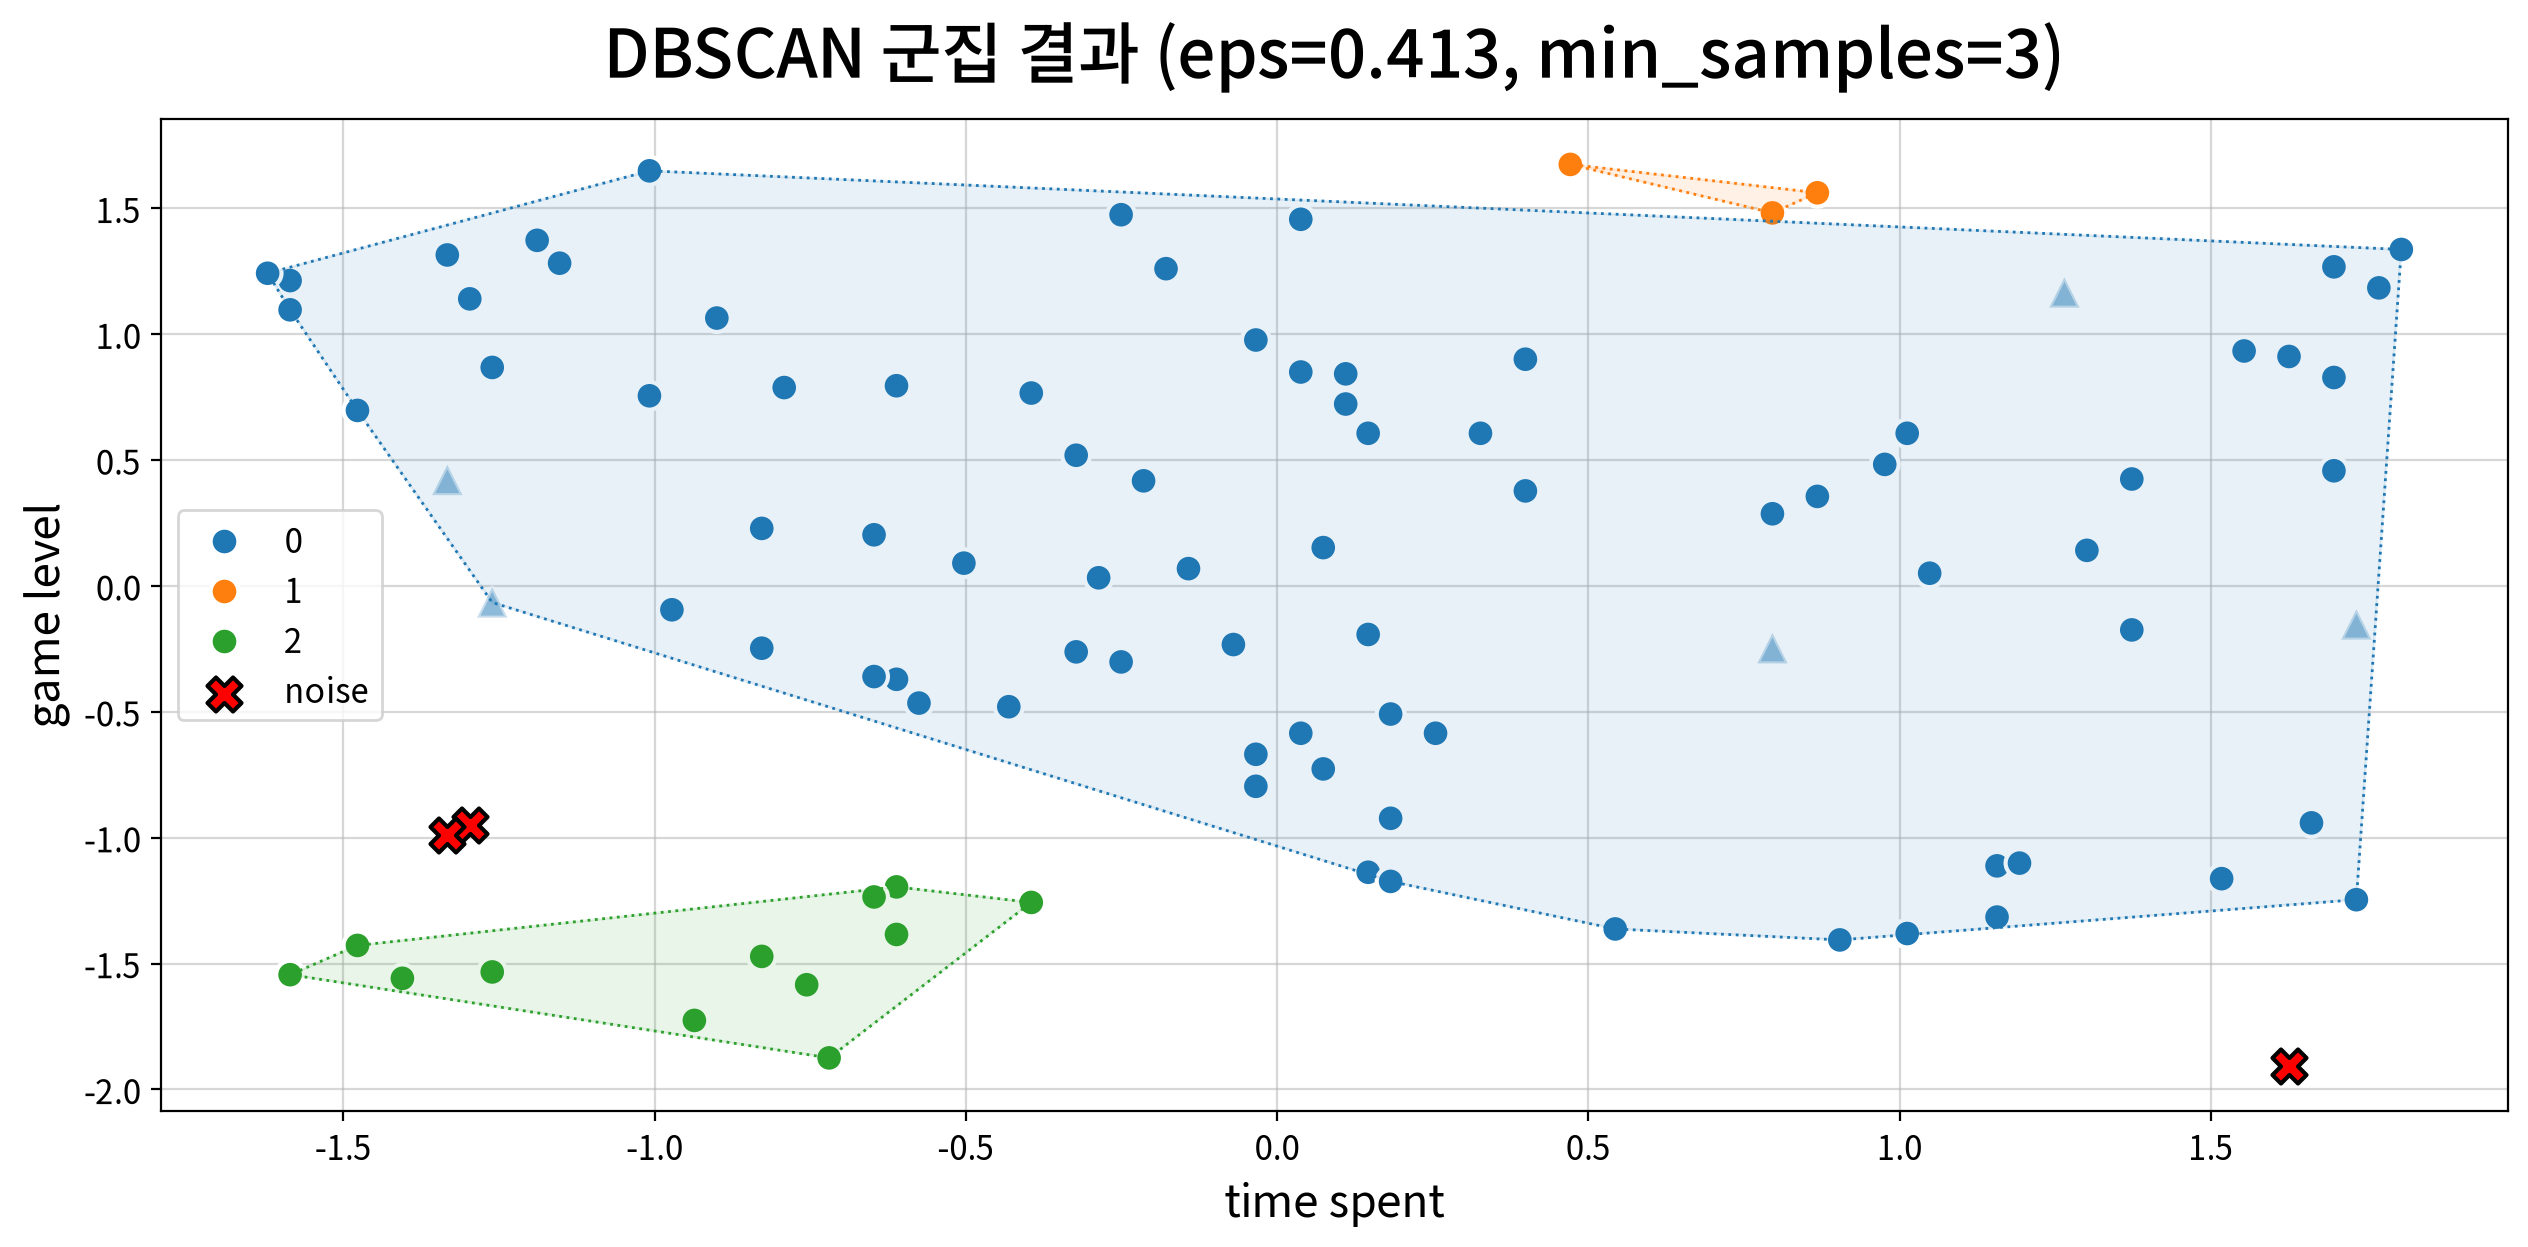

,time spent,game level,그룹번호,벡터유형
0,-0.251,1.475,0,core
1,0.326,0.607,0,core
2,-0.612,0.795,0,core
3,0.471,1.675,1,core
4,-1.405,-1.559,2,core


In [7]:
# 이미 표준화한 데이터이므로 scaling=None 을 지정한다
estimator, result_df, summary = my_cluster.dbscan(
                                    df, eps=eps, min_samples=k, scaling=None)

result_df.head()

### 4. 도출된 eps와 k값을 활용한 군집 (2/2)

In [8]:
# DBSCAN 군집 결과 시각화 (eps=0.413, min_samples=3)
# 색상: 0, 1 = 군집 / X(빨간색) = noise


#### 군집 비교

| | 7단원 (근거 없음) | 이번 단원 (k-distance) |
|---|---|---|
| eps | 0.5 | 약 0.41 |
| min_samples | 5 | 3 |
| 군집 개수 | 2개 | 2개 |
| 노이즈 | 5개 (5.0%) | 3개 (3.0%) |

**군집 해석 예시**
- 오래 하고 레벨 높은 그룹 / 짧게 하고 레벨 낮은 그룹 / 그 중간
- ❌ 어디에도 속하지 않는 특이 사용자 — 그래프에서 빨간 X로 표시된 점들

> 📌 DBSCAN은 그 자체로 최종 결론을 내는 도구가 아니다 — **이상한 데이터를 먼저 걸러내는 용도**로 쓰는 경우가 훨씬 많다.


## #03. 모듈화 기능 확인

### □ 함수로 eps 구하기

앞서 단계별로 짰던 로직이 `/helpers/my_cluster.py`의 `best_eps()` 함수로 모듈화되어 있다.


[k-distance] min_samples = 3, 최적의 eps = 0.4125
  · 꺾이는 위치 = 91번째 데이터 (전체 100개 중)
  · 노이즈 후보 = 8개 (거리가 eps 보다 먼 데이터)


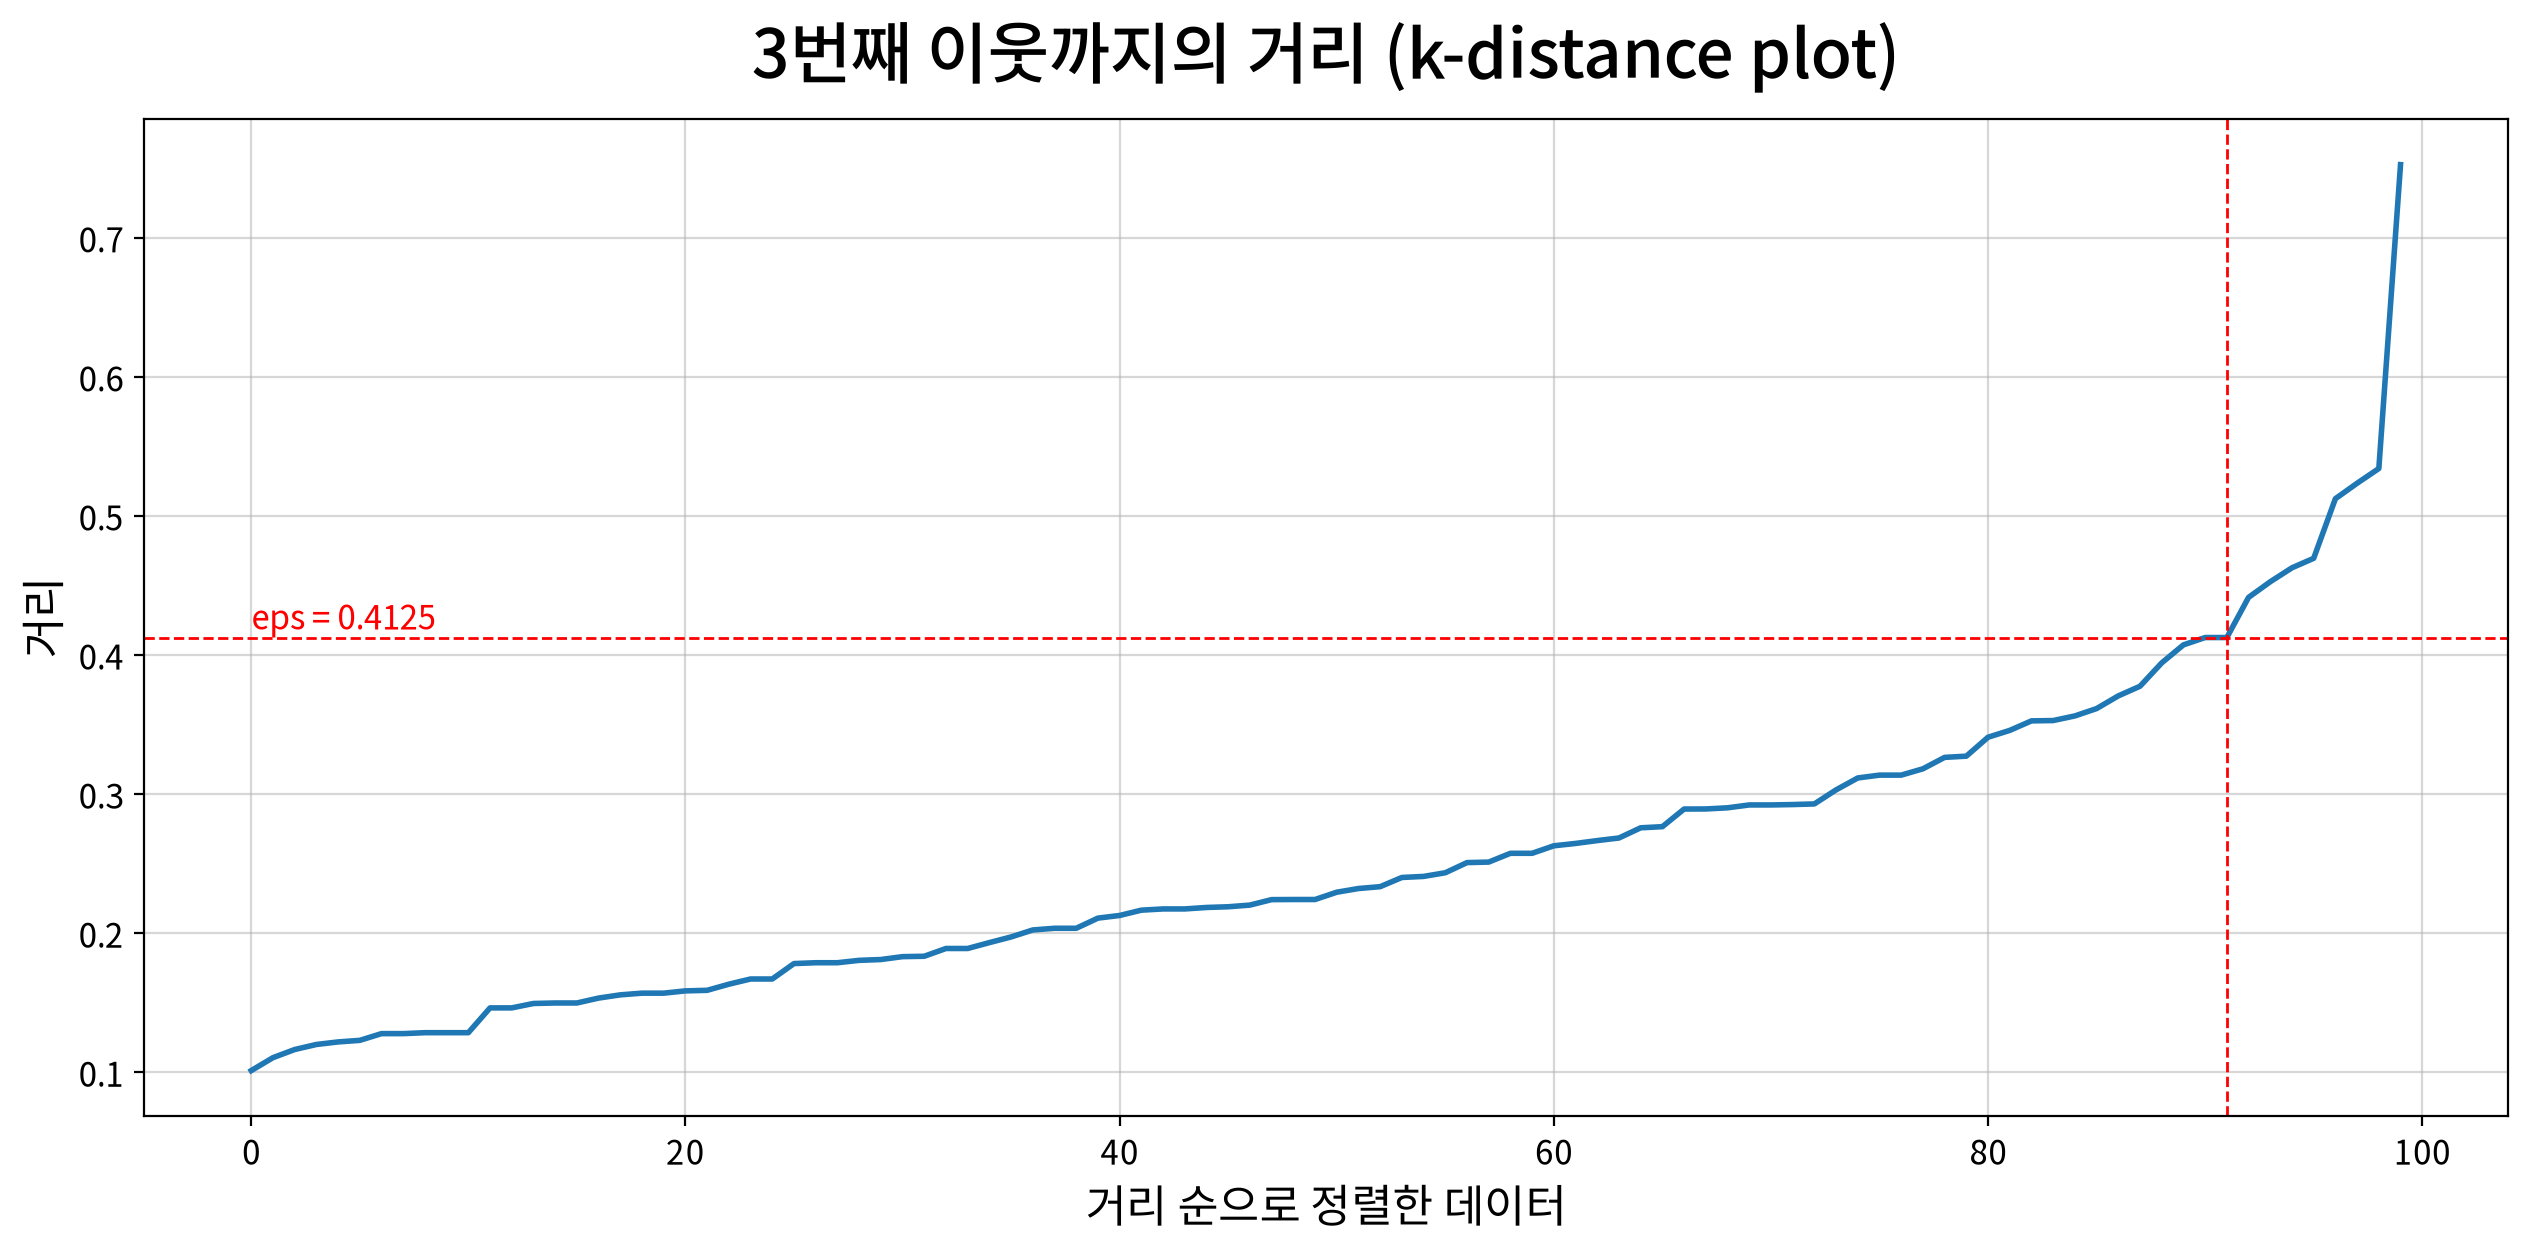

자동으로 찾은 eps 후보: 0.4125


,순위,3번째 이웃까지의 거리
0,1,0.101
1,2,0.110
2,3,0.116
3,4,0.120
4,5,0.122


In [9]:
# 이미 표준화한 데이터이므로 scaling=None 을 지정한다
auto_eps, kdist_df = my_cluster.best_eps(df, min_samples=min_samples, scaling=None)

print(f"자동으로 찾은 eps 후보: {auto_eps:.4f}")
kdist_df.head()

# 연습문제: 그 반경 2.0은 어디서 나온 숫자인가 (1/2) — 근거를 대라

□ 당신은 반경 2.0으로 특이 거래처 15곳을 걸러낸 그 담당자입니다.

> **"기준을 바꾸면 답도 바뀌는 숫자를 근거라고 부를 수는 없습니다.**
> **반경을 데이터에서 끌어내 오고, 그렇게 해도 지난 결론이 그대로인지 보고하세요"**

지난 보고에서 당신은 밀집도로 거래처 440곳을 훑어 어디에도 속하지 못한 15곳을 찾아냈고, 이들을 무리에서 빼는 대신 따로 관리하자는 안을 올렸습니다.

보고서를 읽던 팀장이 표의 한 줄에 밑줄을 긋고 되묻습니다.

> **"반경 2.0. 이 숫자는 어디서 나왔나. 노이즈 비율이 5% 밑으로 처음 떨어져서 골랐다고 했지. 그럼 기준을 3%로 잡았으면 2.5를 골랐을 것 아닌가."**

그래서 이번에는 반경을 눈대중으로 고르지 않고 데이터에서 끌어냅니다.

각 거래처에서 가까운 이웃 몇 곳까지의 거리를 재어 작은 순으로 늘어놓으면, 끝부분에서 거리가 급격히 치솟는 구간이 나타납니다. 그 치솟기 직전의 거리가 곧 반경의 근거입니다. 데이터 준비는 지난번과 같습니다.

채널·지역은 빼고, 큰 거래처 때문에 치우친 지출액을 완만하게 만든 뒤 표준화합니다.

다만 변수가 6개이므로 한 무리로 인정할 최소 이웃 수는 **10**으로 고정합니다.

---

# 연습문제: 그 반경 2.0은 어디서 나온 숫자인가 (2/2) — 문제

**문제 1.** 이웃이 가장 멀리 떨어져 있는 거래처는 열 곳의 이웃을 채우려면 반경을 얼마까지 벌려야 하나요?
*(소수 셋째 자리 반올림)*

**문제 2.** 그 거리들을 작은 순으로 늘어놓으면 끝부분에서 급격히 치솟습니다. 치솟기 직전의 꺾이는 지점에서 읽어낸 반경은 얼마인가요? *(소수 셋째 자리 반올림)*

**문제 3.** 그 반경으로 다시 나눴을 때, 반경 안에 최소 이웃 수를 채워 무리의 몸통을 이루는 거래처는 몇 곳인가요? *(정수 1개, 단위: 곳)*

**문제 4.** 지난 보고에서는 어디에도 속하지 못한 거래처가 15곳이었습니다. 근거를 갖춰 반경을 다시 정한 이번에는 몇 곳인가요? *(정수 1개, 단위: 곳)*

**문제 5.** 팀장에게 "결론은 크게 달라지지 않았다"고 보고하려면 두 결과가 얼마나 겹치는지를 수치로 보여야 합니다. 지난번 결과와 이번 결과의 일치도는 얼마인가요? *(소수 셋째 자리 반올림)*